In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import os
import pandas as pd
import warnings
import collections

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
import muon as mu
from muon import MuData
from anndata import AnnData
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer

import common_data

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
pd.options.display.max_columns = 100

## Read in single-cell object

## Cell type abundance data

In [5]:
abundance = pd.read_csv(common_data.SC_CLUSTERS)

In [6]:
cell_columns = [
    'LYMPHO_NNORMED:B cells',
    'LYMPHO_NNORMED:CD4 T cells',
    'LYMPHO_NNORMED:CD8 T cells',
    'LYMPHO_NNORMED:Classical monocytes-1 CCR2',
    'LYMPHO_NNORMED:Classical monocytes-2 IL1B',
    'LYMPHO_NNORMED:DC1',
    'LYMPHO_NNORMED:DC2',
    #'LYMPHO_NNORMED:Hematopoietic stem cells',
    'LYMPHO_NNORMED:MRC1+C1QA+',
    'LYMPHO_NNORMED:MRC1+C1QA-',
    'LYMPHO_NNORMED:Migratory DC',
    'LYMPHO_NNORMED:NUPR1+ Macs',
    'LYMPHO_NNORMED:Non-classical monocytes',
    'LYMPHO_NNORMED:Perivascular macrophages',
    'LYMPHO_NNORMED:Plasma cells',
    'LYMPHO_NNORMED:Proliferating CD4 T cells',
    'LYMPHO_NNORMED:Proliferating CD8 T cells',
    'LYMPHO_NNORMED:Proliferating NUPR1+ Macs',
    'LYMPHO_NNORMED:Proliferating gdT cells',
    'LYMPHO_NNORMED:Proliferating plasma cells',
    'LYMPHO_NNORMED:Tregs',
    'LYMPHO_NNORMED:gdT cells',
    'LYMPHO_NNORMED:pDC',
    'LYMPHO_NNORMED:Neutrophils percent',
]

Great, these are already mapped to single-cell by BAL.

In [7]:
abundance_trim = abundance[['bal_barcode'] + cell_columns].copy()
abundance_trim.columns = abundance_trim.columns.str.replace('LYMPHO_NNORMED:', '')

Adding healthy volunteer data

In [8]:
sc_meta = pd.read_csv(common_data.SC_META, index_col=0)

/tmp/ipykernel_2014538/1859825940.py:1: DtypeWarning: Columns (16,17,25,31,32,35,37,40,41,52,54,56,57,58,66) have mixed types. Specify dtype option on import or set low_memory=False.
  sc_meta = pd.read_csv(common_data.SC_META, index_col=0)


In [9]:
healthy_counts = sc_meta.loc[
    sc_meta.cohort.eq('Healthy control')
].groupby(['bal_barcode', 'Level_6']).size().reset_index(name='cnt')

Check we don't have epithelial or mast cells

In [10]:
healthy_counts.Level_6.unique()

array(['B cells', 'CD4 T cells', 'CD8 T cells',
       'Classical monocytes-1 CCR2', 'Classical monocytes-2 IL1B', 'DC1',
       'DC2', 'Hematopoietic stem cells', 'Interstitial macrophages',
       'MRC1+C1QA+', 'MRC1+C1QA-', 'Mast cells', 'Migratory DC',
       'NUPR1+ Macs', 'Non-classical monocytes',
       'Proliferating CD4 T cells', 'Proliferating CD8 T cells',
       'Proliferating NUPR1+ Macs', 'Tregs', 'gdT cells', 'pDC',
       'Proliferating plasma cells', 'Plasma cells',
       'Proliferating gdT cells'], dtype=object)

In [11]:
healthy_counts = healthy_counts.loc[healthy_counts.Level_6.ne('Mast cells')]

For consistency we don't exclude HSC here, but later

In [12]:
healthy_flow = pd.read_csv(common_data.DATA / '00_metadata/healthy_volunteers_flow.csv', index_col=0)

In [13]:
healthy_pct = healthy_counts.pivot_table(
    index='bal_barcode',
    columns='Level_6',
    values='cnt',
    fill_value=0
)

In [14]:
healthy_pct = healthy_pct.merge(
    healthy_flow[['Sample', 'Neutrophils', 'Eosinophils', 'Total']],
    left_on='bal_barcode',
    right_on='Sample',
    suffixes=('', '_flow')
)

In [15]:
healthy_pct.loc[:, healthy_counts.Level_6.unique()] = healthy_pct.loc[:, healthy_counts.Level_6.unique()].div(
    healthy_pct.loc[:, healthy_counts.Level_6.unique()].sum(axis=1),
    axis=0
)

In [16]:
healthy_pct = healthy_pct.rename(columns={'Neutrophils': 'Neutrophils percent'})

In [17]:
healthy_pct.loc[:, healthy_counts.Level_6.unique()] = healthy_pct.loc[:, healthy_counts.Level_6.unique()].mul(
    (healthy_pct.Total - healthy_pct.Eosinophils - healthy_pct['Neutrophils percent']) / 100,
    axis=0
)

In [18]:
healthy_pct['Neutrophils percent'] /= 100

In [19]:
healthy_pct = healthy_pct.rename(columns={
    'Sample': 'bal_barcode'
}).drop(columns=['Eosinophils', 'Total', 'Hematopoietic stem cells'])

In [20]:
abundance_trim = pd.concat([
    abundance_trim.rename(columns={'Perivascular macrophages': 'Interstitial macrophages'}),
    healthy_pct
], axis=0)

Multiple each by 10k

In [21]:
for col in abundance_trim.columns:
    if col != 'bal_barcode':
        abundance_trim[col] = abundance_trim[col] * 10000

In [22]:
abundance_trim.select_dtypes(include='float64').sum(axis=1).value_counts(dropna=False)

10000.000000    28
10000.000000    16
10000.000000    13
10000.000000    13
10000.000000     9
                ..
9998.418466      1
9998.238893      1
9999.432073      1
9999.487068      1
9883.900000      1
Length: 173, dtype: int64

Not all sum to exactly 10k due to Hematopoetic Stem Cells

Run log(1p) just like we do in single-cell

In [23]:
for col in abundance_trim.columns:
    if col != 'bal_barcode':
        abundance_trim[col] = np.log1p(abundance_trim[col])

See what distributions look like

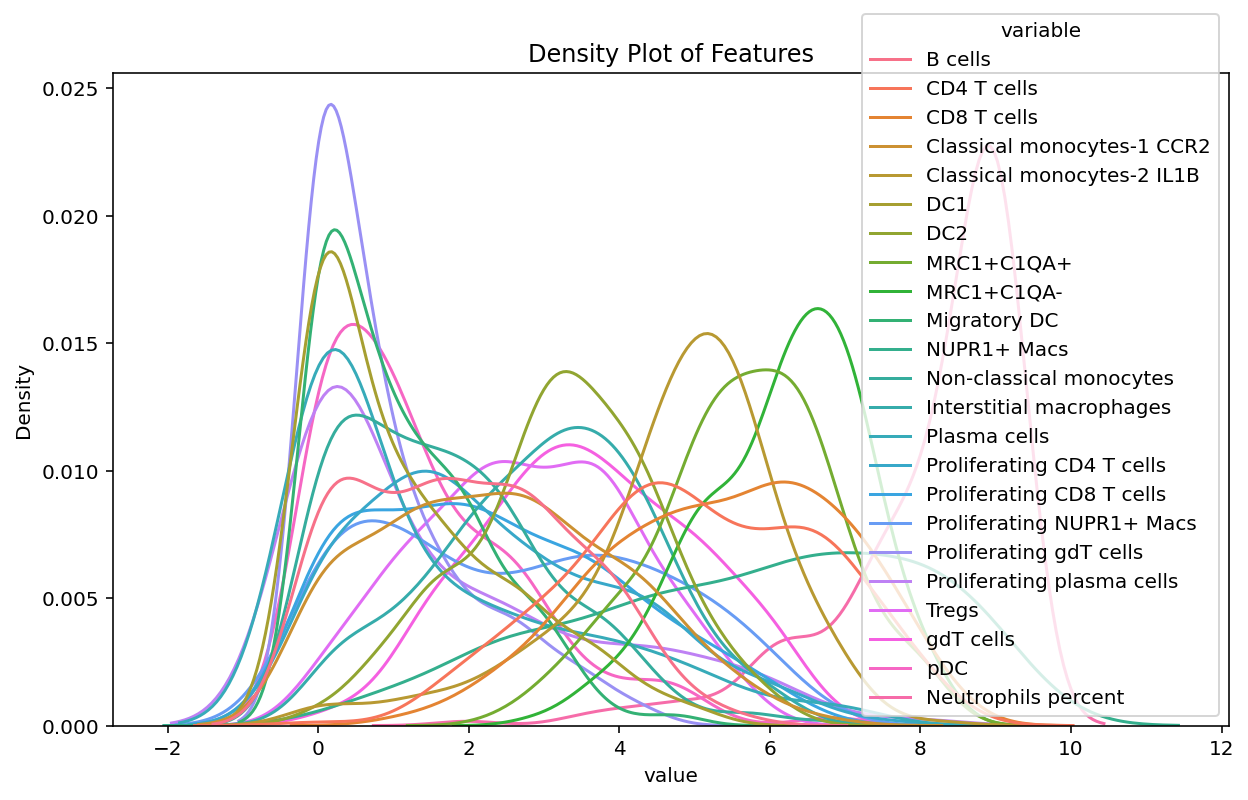

In [24]:
melted_df = pd.melt(abundance_trim.select_dtypes(include='float64'))
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False)
plt.title('Density Plot of Features')
plt.show()

Z score normalization

In [25]:
# Initialize the StandardScaler
scaler = StandardScaler()
# Z-score normalize all columns
flow_numerical = abundance_trim.select_dtypes(include='float64')
flow_zscore = pd.DataFrame(scaler.fit_transform(flow_numerical), columns=flow_numerical.columns)

See what distributions look like

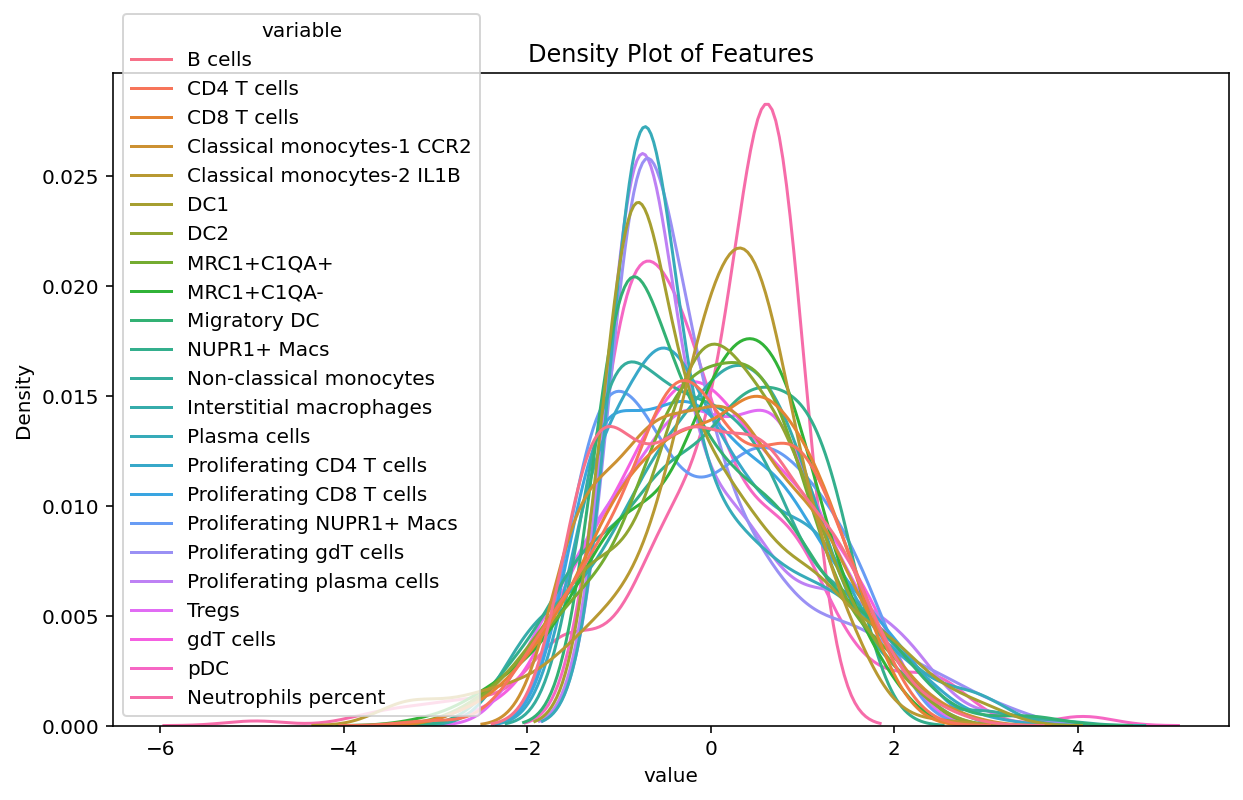

In [26]:
melted_df = pd.melt(flow_zscore)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False)
plt.title('Density Plot of Features')
plt.show()

Now run quantile normalization across cell types

In [27]:
# Create a QuantileTransformer
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)

# Apply quantile normalization to each feature
normalized_df = pd.DataFrame(quantile_transformer.fit_transform(flow_zscore), columns=flow_zscore.columns)

/projects/b1196/envs/serniczek_mofa/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:2663: UserWarning: n_quantiles (1000) is greater than the total number of samples (249). n_quantiles is set to n_samples.
  warnings.warn(


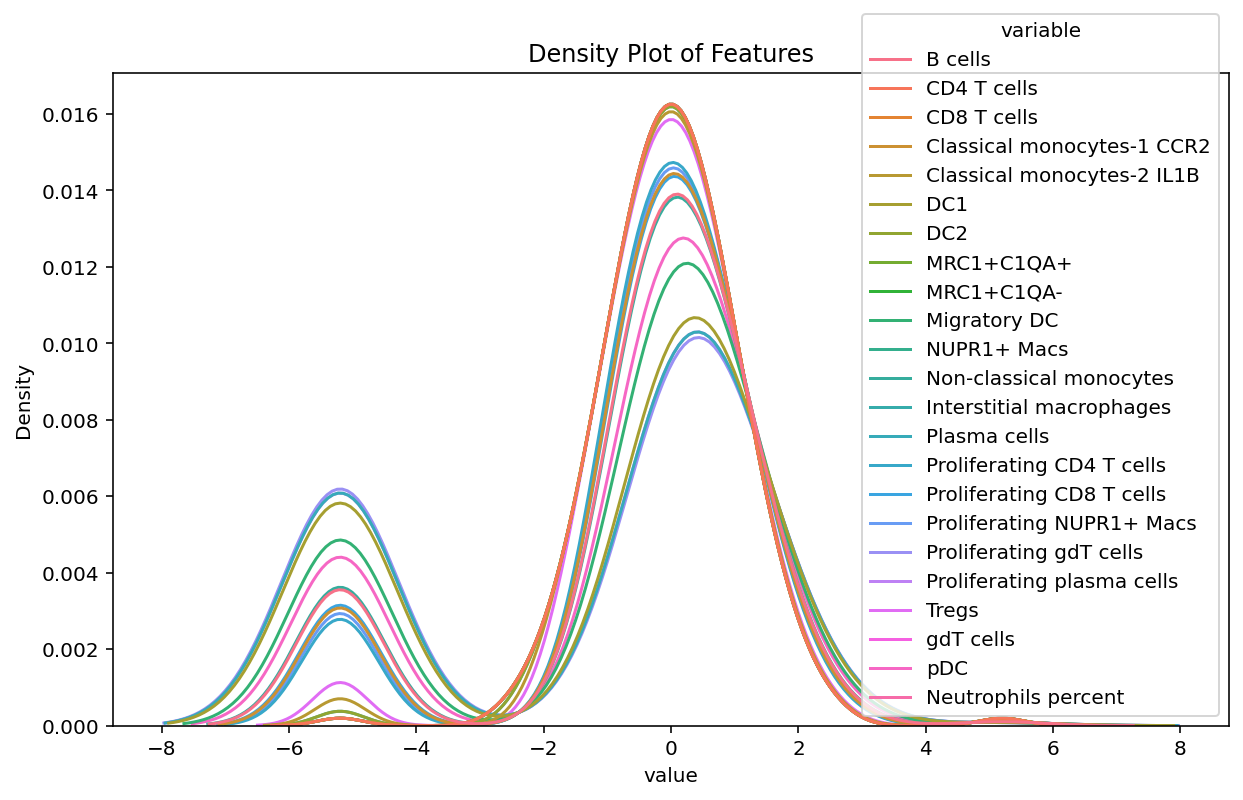

In [28]:
melted_df = pd.melt(normalized_df)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False)
plt.title('Density Plot of Features')
plt.show()

In [29]:
cta_adata = AnnData(normalized_df.values)
cta_adata.obs_names = abundance_trim['bal_barcode'].values
cta_adata.var_names = [f"{x}_counts" for x in normalized_df.columns]

/tmp/ipykernel_2014538/306470151.py:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  cta_adata = AnnData(normalized_df.values)


In [30]:
mdata = MuData({"cell_type_abundance": cta_adata})

In [31]:
mdata

MuData object with n_obs × n_vars = 249 × 23
  1 modality
    cell_type_abundance:	249 x 23

This is the intersection of scRNAseq and flow of SCRIPT + Healthy volunteers (8 out of 9)

In [32]:
abundance_trim.shape

(249, 24)

## Prepare single-cell

MOFA pseudobulks:
- SCRIPT and healthy control samples
- 50 cells required per sample (done at pseudobulk level in `05_pseudobulk/01_make_pseudobulk`)
- no ribosomal or mitochondrial genes (mitochondrial removed in pseudobulk step)
- for a gene to be included, 80% of samples have to express the gene
- cell type included if >= 50% of samples have a sample
- sample included if ???

In [33]:
sc_labels = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [34]:
sc_labels = sc_labels.loc[sc_labels.cohort.isin(['SCRIPT', 'Healthy control'])]

In [35]:
sc_labels.shape

(272, 78)

In [36]:
SAMPLE_THRESHOLD = sc_labels.shape[0] // 2

In [ ]:
PSEUDOBULK_BASE = common_data.DATA / '05_pseudobulk/01_all_pseudobulk'

In [38]:
def filter_genes(
        counts: pd.DataFrame,
        remove_ribo: bool = True,
        detection_threshold: float = 0.8
) -> pd.DataFrame:
    """Filter genes based on expression criteria.

    Args:
        counts (pd.DataFrame): DataFrame with genes as rows and samples as columns.
        remove_ribo (bool, optional): Whether to remove ribosomal genes.
        detection_threshold (float, optional): Remove genes not detected in this fraction of samples.

    Returns:
        pd.DataFrame: Filtered DataFrame with selected genes.
    """
    # Calculate the number of samples where each gene is expressed (non-zero)
    expressed_in_samples = (counts > 0).sum(axis=1)

    # Filter genes that are expressed in more than SAMPLE_THRESHOLD samples
    filtered_counts = counts[expressed_in_samples > counts.shape[1] * detection_threshold]

    if remove_ribo:
        idx = ~filtered_counts.index.str.startswith(('RPS', 'RPL'))
        filtered_counts = filtered_counts.loc[idx]

    return filtered_counts.copy()

In [39]:
for ct_dir in sorted(PSEUDOBULK_BASE.iterdir()):
    if not ct_dir.is_dir():
        continue

    ct_meta = pd.read_csv(ct_dir / 'meta.csv', index_col=0)
    if ct_meta.shape[0] < SAMPLE_THRESHOLD:
        print(f"Skipping {ct_dir.name} with {ct_meta.shape[0]} samples (less than {SAMPLE_THRESHOLD})")
        continue

    ct_meta = ct_meta.loc[ct_meta['sample'].isin(sc_labels.bal_barcode)]

    counts = pd.read_csv(ct_dir / 'count.txt', sep='\t', index_col=0)
    counts = counts.loc[:, ct_meta['sample']]
    n_genes_before = counts.shape[0]
    counts = filter_genes(counts)
    n_genes_after = counts.shape[0]
    counts.index = ct_meta['cell_type'][0] + '_' + counts.index

    ct_adata = AnnData(counts.T)
    print(f"• {ct_dir.name}: {n_genes_before} -> {n_genes_after} genes after filtering, {ct_meta.shape[0]} samples")
    mdata.mod[f'{ct_meta.cell_type[0]}_sc'] = ct_adata

Skipping AT1_and_AT2 with 8 samples (less than 136)
Skipping B_cells with 60 samples (less than 136)


/tmp/ipykernel_2014538/677610265.py:19: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ct_adata = AnnData(counts.T)


• CD4_T_cells: 17816 -> 9521 genes after filtering, 238 samples


/tmp/ipykernel_2014538/677610265.py:19: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ct_adata = AnnData(counts.T)


• CD8_T_cells: 17816 -> 9700 genes after filtering, 251 samples
Skipping Ciliated_cells with 70 samples (less than 136)
Skipping Classical_monocytes-1_CCR2 with 89 samples (less than 136)


...

/tmp/ipykernel_2014538/677610265.py:19: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ct_adata = AnnData(counts.T)


• MRC1+C1QA-: 17816 -> 11189 genes after filtering, 267 samples
Skipping Mast_cells with 19 samples (less than 136)
Skipping Migratory_DC with 13 samples (less than 136)


/tmp/ipykernel_2014538/677610265.py:19: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ct_adata = AnnData(counts.T)


• NUPR1+_Macs: 17816 -> 11467 genes after filtering, 237 samples
Skipping Non-classical_monocytes with 31 samples (less than 136)
Skipping Perivascular_macrophages with 127 samples (less than 136)
Skipping Plasma_cells with 59 samples (less than 136)
Skipping Proliferating_CD4_T_cells with 86 samples (less than 136)
Skipping Proliferating_CD8_T_cells with 83 samples (less than 136)
Skipping Proliferating_NUPR1+_Macs with 115 samples (less than 136)
Skipping Proliferating_gdT_cells with 11 samples (less than 136)
Skipping Proliferating_plasma_cells with 69 samples (less than 136)
Skipping Secretory_cells with 47 samples (less than 136)
Skipping Tregs with 124 samples (less than 136)
• gdT_cells: 17816 -> 8460 genes after filtering, 157 samples
Skipping pDC with 25 samples (less than 136)


/tmp/ipykernel_2014538/677610265.py:19: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  ct_adata = AnnData(counts.T)


In [41]:
mdata

MuData object with n_obs × n_vars = 249 × 23
  9 modalities
    cell_type_abundance:	249 x 23
    CD4 T cells_sc:	238 x 9521
    CD8 T cells_sc:	251 x 9700
    Classical monocytes-2 IL1B_sc:	225 x 9488
    DC2_sc:	142 x 9923
    MRC1+C1QA+_sc:	265 x 11017
    MRC1+C1QA-_sc:	267 x 11189
    NUPR1+ Macs_sc:	237 x 11467
    gdT cells_sc:	157 x 8460

## Normalization for each pseudobulk

In [42]:
test = mdata.mod['CD4 T cells_sc']

In [43]:
test_df = pd.DataFrame(test.X)
test_df.index = test.obs.index
test_df.columns = test.var.index

Need to normalize each sample to the same sum

In [44]:
normalized_sum = test_df.div(test_df.sum(axis=1), axis=0) * 10000

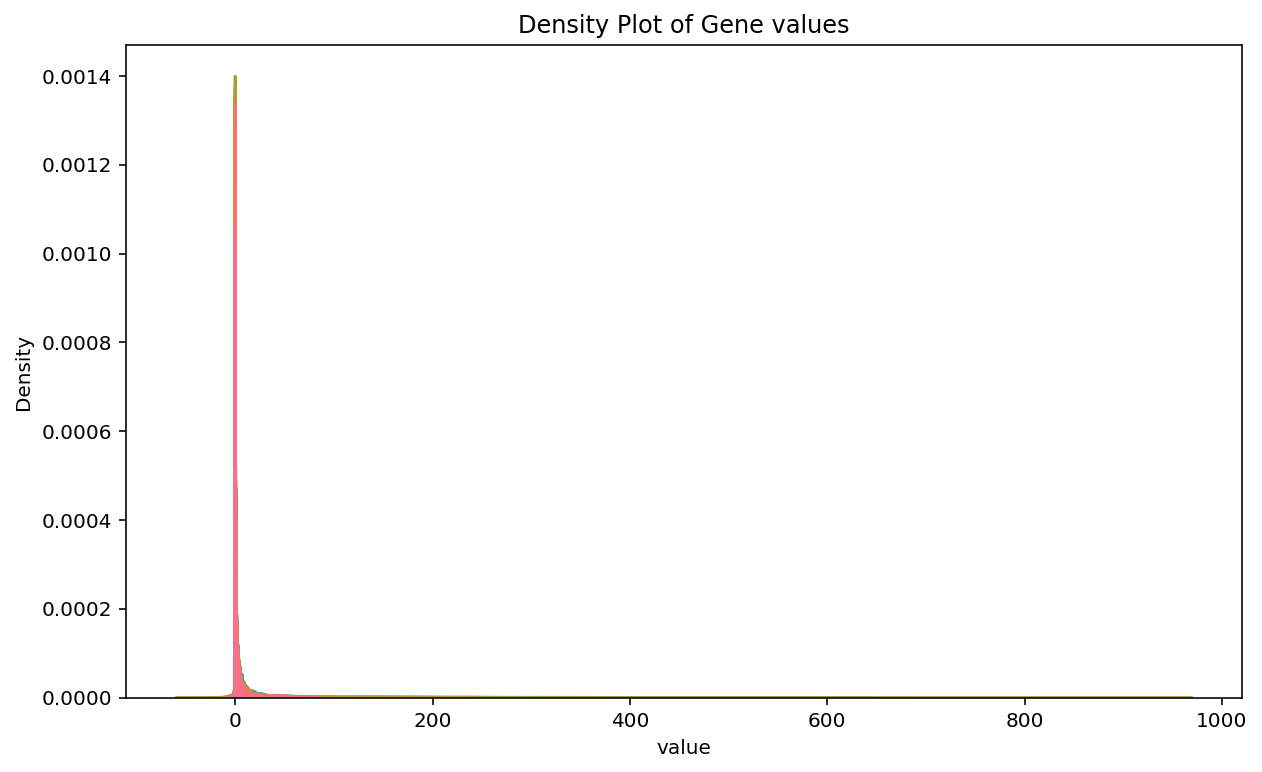

In [45]:
melted_df = pd.melt(normalized_sum)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False, legend=False)
plt.title('Density Plot of Gene values')
plt.show()

Zscore genes

In [46]:
# Z-score normalize all columns
df_zscore = pd.DataFrame(scaler.fit_transform(normalized_sum), columns=normalized_sum.columns)

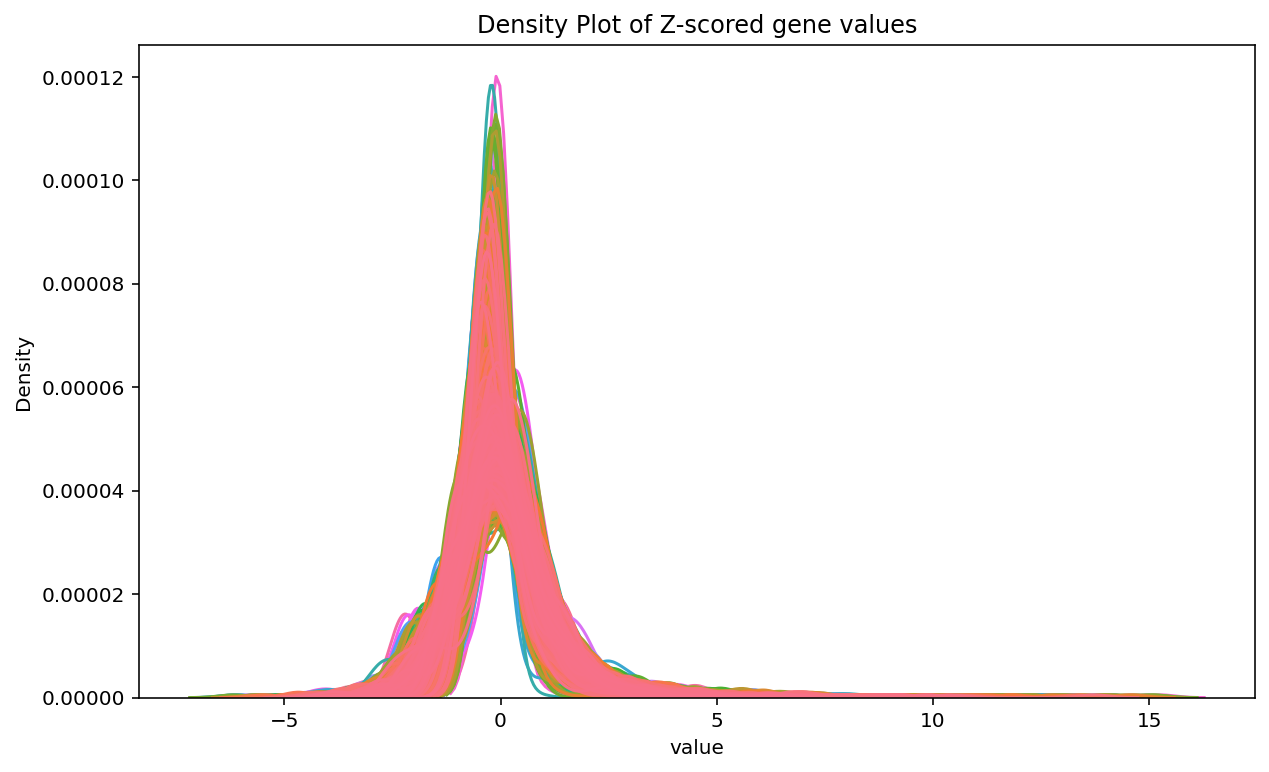

In [47]:
melted_df = pd.melt(df_zscore)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False, legend=False)
plt.title('Density Plot of Z-scored gene values')
plt.show()

These look pretty well aligned

In [48]:
# sample-wide quantile normalization
sample_norm = pd.DataFrame(
    quantile_transformer.fit_transform(df_zscore.T),
    columns=df_zscore.index
).T
sample_norm.columns = df_zscore.columns

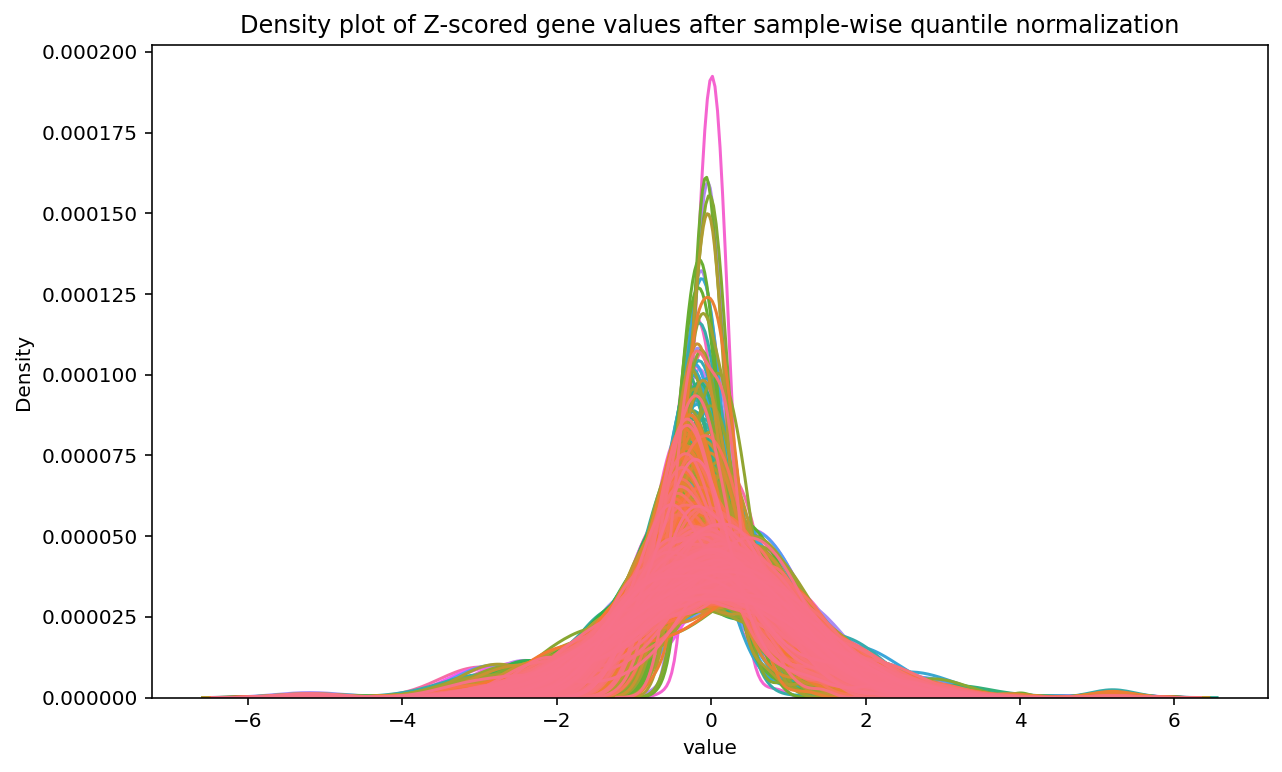

In [49]:
melted_df = pd.melt(sample_norm)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False, legend=False)
plt.title('Density plot of Z-scored gene values after sample-wise quantile normalization')
plt.show()

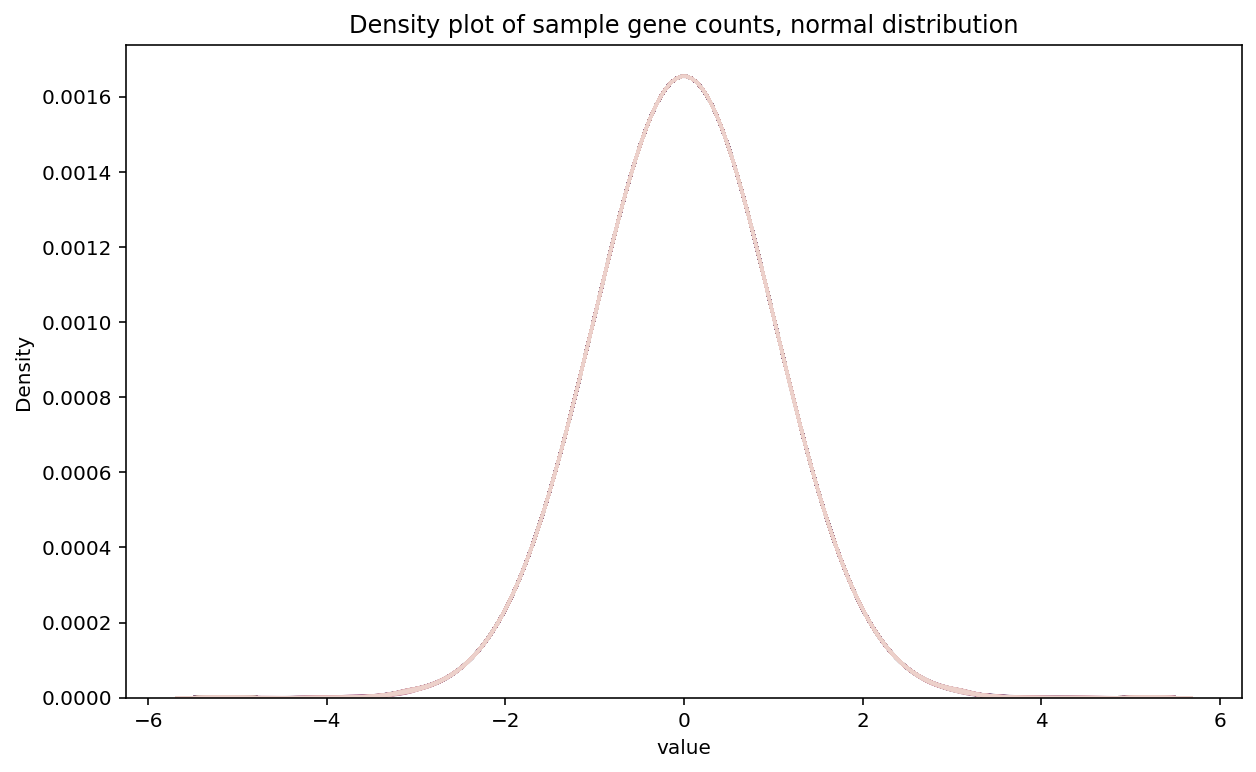

In [50]:
melted_df = pd.melt(sample_norm.T)
# Create a density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=melted_df, x='value', hue='variable', fill=False, legend=False)
plt.title('Density plot of sample gene counts, normal distribution')
plt.show()

### This looks good, going to proceed with all views

Switch to do sample then gene QN

In [51]:
for k in mdata.mod.keys():
    if k.endswith('_sc'):
        test = mdata.mod[k]
        test_df = pd.DataFrame(test.X)
        test_df.index = test.obs.index
        test_df.columns = test.var.index

        # normalize sample-wide totals
        normalized_sum = test_df.div(test_df.sum(axis=1), axis=0) * 10000

        # z-score genes
        df_zscore = pd.DataFrame(scaler.fit_transform(normalized_sum), columns=normalized_sum.columns)

        # sample-wide quantile normalization
        sample_norm = pd.DataFrame(
            quantile_transformer.fit_transform(df_zscore.T),
            columns=df_zscore.index
        ).T
        sample_norm.columns = df_zscore.columns

        mdata.mod[k].X = sample_norm.values
        mdata.update()
        print(f"finished {k}")

finished CD4 T cells_sc
finished CD8 T cells_sc
finished Classical monocytes-2 IL1B_sc
finished DC2_sc
finished MRC1+C1QA+_sc
finished MRC1+C1QA-_sc
finished NUPR1+ Macs_sc
finished gdT cells_sc


### Save to h5mu file also

In [52]:
mdata

MuData object with n_obs × n_vars = 272 × 80788
  9 modalities
    cell_type_abundance:	249 x 23
    CD4 T cells_sc:	238 x 9521
    CD8 T cells_sc:	251 x 9700
    Classical monocytes-2 IL1B_sc:	225 x 9488
    DC2_sc:	142 x 9923
    MRC1+C1QA+_sc:	265 x 11017
    MRC1+C1QA-_sc:	267 x 11189
    NUPR1+ Macs_sc:	237 x 11467
    gdT cells_sc:	157 x 8460

### Examine number of modalities for each sample

8    82
9    75
7    57
6    29
5    17
4     9
2     3
dtype: int64

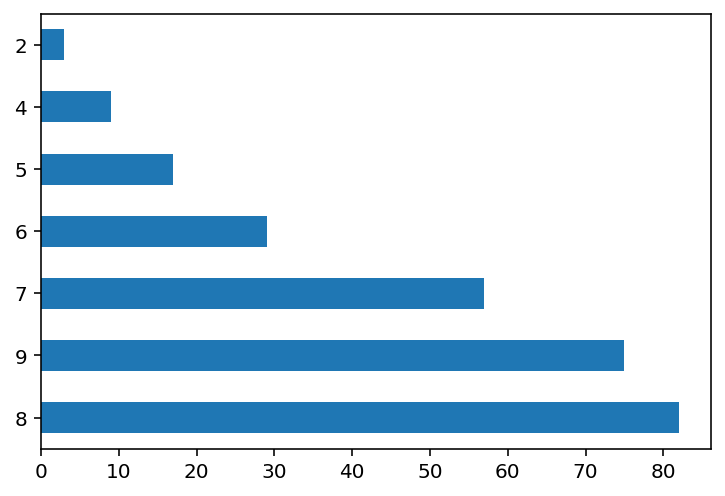

In [53]:
n_modalities = collections.Counter()
for key in mdata.mod.keys():
    for obs in mdata.mod[key].obs_names:
        n_modalities[obs] += 1
pd.Series(n_modalities).value_counts().plot.barh()
pd.Series(n_modalities).value_counts()

In [ ]:
for sample, count in n_modalities.items():
    if count > 4:
        continue
    mods = []
    for key in mdata.mod.keys():
        if sample in mdata.mod[key].obs_names:
            mods.append(key)
    print(f"{sample}: {mods}")

Let's remove 3 samples with just 2 modalities

In [ ]:
to_remove = [sample for sample, count in n_modalities.items() if count < 3]
to_remove

In [56]:
mdata = mdata[~mdata.obs_names.isin(to_remove)].copy()

In [57]:
mdata

MuData object with n_obs × n_vars = 269 × 80788
  9 modalities
    cell_type_abundance:	247 x 23
    CD4 T cells_sc:	238 x 9521
    CD8 T cells_sc:	251 x 9700
    Classical monocytes-2 IL1B_sc:	225 x 9488
    DC2_sc:	142 x 9923
    MRC1+C1QA+_sc:	264 x 11017
    MRC1+C1QA-_sc:	266 x 11189
    NUPR1+ Macs_sc:	235 x 11467
    gdT cells_sc:	157 x 8460

In [ ]:
(common_data.DATA / '06_mofa').mkdir(exist_ok=True)

In [ ]:
mdata.write(common_data.DATA / '06_mofa' / '01_mofa.h5mu')

## Set up MOFA

In [ ]:
mu.tl.mofa(
    mdata,
    use_obs='union',
    center_groups=False,
    outfile=common_data.DATA / '06_mofa' / '01_mofa_model.hdf5',
    n_factors=10
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='cell_type_abundance' group='group1' with N=269 samples and D=23 features...
Loaded view='CD4 T cells_sc' group='group1' with N=269 samples and D=9521 features...
Loaded view='CD8 T cells_sc' group='group1' with N=269 samples and D=9700 features...
Loaded view='Classical monocytes-2 IL1B_sc' group='group1' with N=269 samples and D=9488 features...
Loaded view='DC2_sc

Save model

In [ ]:
for i in range(0, mdata.varm['LFs'].shape[1]):
    mdata.var[f"factor_{i+1}_loading"] = mdata.varm['LFs'][:, i]

for i in range(0, mdata.varm['LFs'].shape[1]):
    mdata.obs[f"factor_{i+1}_score"] = mdata.obsm['X_mofa'][:, i]

In [ ]:
SAVE_DIR = common_data.DATA / '06_mofa'
mdata.obs.to_csv(f'{SAVE_DIR}/factor_matrix.csv')

In [64]:
mdata.var.to_csv(f'{SAVE_DIR}/feature_weights.csv')

In [65]:
mdata.write_h5mu(SAVE_DIR / '01_mofa_fitted.h5mu')